Discovering the Higgs boson: https://colab.research.google.com/github/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/HyyAnalysis.ipynb#scrollTo=KJu173g1Sh38

# Set up

Install required Python packages. You only need to do this once. Hope it works first try 🤞

In [1]:
import sys
%pip install atlasopenmagic
#from atlasopenmagic import install_from_environment

# problematic line, so I'll just try to install as I need to
#install_from_environment()

Note: you may need to restart the kernel to use updated packages.


c:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\.venv\Scripts\python.exe: No module named pip


Imports for the tutorial.

In [44]:
import uproot # for reading .root files
#import time # to measure time to analyse
#import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support

Access data from the ATLAS OpenData Portal, so no downloading here. First import the module and load the Open Data release. Then, load the Open Data ntuples (which have already been selected/skimmed) to contain at least 2 photons.

In [3]:
import atlasopenmagic as atom
atom.available_releases()
atom.set_release('2025e-13tev-beta')
skim = 'GamGam'

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets: 100%|██████████| 374/374 [00:01<00:00, 297.88datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Get the list of files to go through. Use 'cache' to download the files locally.

In [4]:
files_list = atom.get_urls('data', skim, protocol='https', cache=True)

Try accessing 'data15_periodD' in the ATLAS Open Data directory as an example.

In [69]:
data15_periodD = files_list[0]
print(f"{data15_periodD = }")
print("files_list: ")
for f in files_list:
    print(f)

data15_periodD = 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root'
files_list: 
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root
simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodA.GamG

What does this files_list look like?

In [6]:
print(files_list)
print(len(files_list))

['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root',

Open the data15_periodD file. The file, called a `tree`, contains multiple entries, each representing an event. Each event has a dictionary with keys such as `eventNumber`, `photon_pt` (photon transverse momentun), and more.

In [10]:
#tree = uproot.open(data15_periodD + ":analysis") # ":analysis" opens the tree in desired way
pathname = "C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root"
tree = uproot.open(pathname + ":analysis")
print(f'Number of entries in tree: {tree.num_entries}')
print(f'Keys in the tree: {tree.keys()}')

Number of entries in tree: 63195
Keys in the tree: ['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'sig_ph', 'n_sig_ph', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMediumID', 'lep_isLooseID', 'lep_isTightIso'

See the energies of photons.

In [11]:
tree['photon_e'].arrays()

<Array [{photon_e: [289, 57.5]}, ..., {...}] type='63195 * {photon_e: var *...'>

# Filter for Higgs boson events

The most important variables for the H→γγ analysis.

In [12]:
variables = ["photon_pt","photon_eta","photon_phi","photon_e",
                            "photon_isTightID","photon_ptcone20"]

Filter out events to find the ones that might be a higgs boson.

In [ ]:
# select first entry of tree
entry = tree.arrays(library='ak')[:1]
print(entry)

[{num_events: 1, sum_of_weights: 1, sum_of_weights_squared: 1, ...}]


In [23]:
# cut on the photon reconstruction quality
photon_reconstruction = entry['photon_isTightID']
# isTightID==True means photon is identified as being well reconstructed
photon_reconstruction_cut_bool = (photon_reconstruction[:, 0] == True) & (photon_reconstruction[:, 1]==True) # [:, i] selects the i-th lepton in each event
print("The reconstruction quality of the two photons:", photon_reconstruction[:,0], photon_reconstruction[:,1])
print("Keep event based on reconstruction quality requirements?", photon_reconstruction_cut_bool)
print("-"*80)

# cut on the transverse momentum
photon_pt = entry['photon_pt']
# only events where leading photon has transverse momentum (pt) > 50 GeV and sub-leading photon has pt > 30 GeV are kept
# since the 2 phtons for each entry are ordered, the frist photon is the leading one and the second is the sub-leading one
photon_pt_cut_bool = (photon_pt[:,0] > 50) & (photon_pt[:,1] > 30)
print('The transverse momentum of the two photons:', photon_pt[:,0], photon_pt[:,1])
print('Keep event based on transverse momentum requirements?', photon_pt_cut_bool)
print('-'*80)

# cut on the calorimeter isolation
photon_ptcone20 = entry['photon_ptcone20']
# only events where the individual photon calorimeter isolation is less than 5.5% are kept
photon_caloiso_cut_bool = ((photon_ptcone20[:,0] / photon_pt[:,0]) < 0.055) & ((photon_ptcone20[:,1] / photon_pt[:,1]) < 0.055)
print('The calorimeter isolation of the two photons:', photon_ptcone20[:,0] / photon_pt[:,0], (photon_ptcone20[:,1] / photon_pt[:,1]))
print('Keep event based on calorimeter isolation requirements?', photon_caloiso_cut_bool)
print('-'*80)

# logic here looks flawed to me, but it's in the tutorial
# cut on the pseudorapidity in the barrel/end-cap tranition region
photon_eta = entry['photon_eta']
# only events where the modulus of phton_eta is outside the range 1.37 to 1.52 are kept
condition_0 = (np.abs(photon_eta[:, 0]) < 1.52) | (np.abs(photon_eta[:, 0]) > 1.37)
condition_1 = (np.abs(photon_eta[:, 1]) < 1.52) | (np.abs(photon_eta[:, 1]) > 1.37)

photon_eta_cut_bool = condition_0 & condition_1
print('The eta of the two photons:', photon_eta[:,0], photon_eta[:,1])
print('Keep event based on eta requirements?', photon_eta_cut_bool)
print('-'*80)

# calculate the invariant mass of the 2-photon state
p4 = vector.zip({"pt": entry['photon_pt'], "eta": entry['photon_eta'], "phi": entry['photon_phi'], "e": entry['photon_e']})
invariant_mass = (p4[:, 0] + p4[:, 1]).M # .M calculates the invariant mass
print(f'The invariant mass of the 2-photon state is: {invariant_mass} GeV')
print('-'*80)


The reconstruction quality of the two photons: [True] [True]
Keep event based on reconstruction quality requirements? [True]
--------------------------------------------------------------------------------
The transverse momentum of the two photons: [106] [47.6]
Keep event based on transverse momentum requirements? [True]
--------------------------------------------------------------------------------
The calorimeter isolation of the two photons: [0] [0.174]
Keep event based on calorimeter isolation requirements? [False]
--------------------------------------------------------------------------------
The eta of the two photons: [1.66] [0.637]
Keep event based on eta requirements? [True]
--------------------------------------------------------------------------------
The invariant mass of the 2-photon state is: [160] GeV
--------------------------------------------------------------------------------


Turn the above checks and calculations into a set of functions.

In [25]:
# cut on the photon reconstruction quality
def cut_photon_reconstruction(photon_isTightID):
    # only events which have True for both photons are kept
    return (photon_isTightID[:, 0] == True) & (photon_isTightID[:, 1]==True)

# cut on the transverse momentum
def cut_photon_pt(photon_pt):
    # only events where leading proton's pt > 50 and sub-leading's > 30 are kept
    return (photon_pt[:,0] > 50) & (photon_pt[:,1] > 30)

# cut on the energy isolation
def cut_isolation_pt(photon_ptcone20, photon_pt):
    # only events where calorimeter isolation is less than 5.5% are kept
    return ((photon_ptcone20[:,0]/photon_pt[:,0]) < 0.055) & ((photon_ptcone20[:,1]/photon_pt[:,1]) < 0.055)

# NOTE: I think there's a logic error in this one, from the tutorial
# cut on the pseudorapidity in barrel/end-cap transition region
def cut_photon_eta_transition(photon_eta):
    # only events where the modulus of photon_eta is outside the range 1.37 to 1.52 are kept
    condition_0 = (np.abs(photon_eta[:, 0]) < 1.52) | (np.abs(photon_eta[:, 0]) > 1.37)
    condition_1 = (np.abs(photon_eta[:, 1]) < 1.52) | (np.abs(photon_eta[:, 1]) > 1.37)
    return condition_0 & condition_1

# calculate the invariant mass of the 2-photon state
def calc_mass(photon_pt, photon_eta, photon_phi, photon_e):
    p4 = vector.zip({"pt": photon_pt, "eta": photon_eta, "phi": photon_phi, "e": photon_e})
    invariant_mass = (p4[:, 0] + p4[:, 1]).M # .M calculates the invariant mass
    return invariant_mass

# cut on null diphoton invariant mass
def cut_mass(invariant_mass):
    return invariant_mass != 0

# cut on the pT relative to the invariant mass
# only events where the individual photon pT is larger than 35% of the invariant are kept
def cut_iso_mass(photon_pt, invariant_mass):
    return ((photon_pt[:,0] / invariant_mass) > 0.35) & ((photon_pt[:,1] / invariant_mass) > 0.35)



Apply above functions over the entire data tree.

In [35]:
# list to hold all data for this sample
sample_data = []

# perform the cuts for each data entry in the tree
for data in tree.iterate(variables, library='ak'):
    photon_isTightID = data['photon_isTightID']
    data = data[cut_photon_reconstruction(photon_isTightID)]

    photon_pt = data['photon_pt']
    data = data[cut_photon_pt(photon_pt)]

    data = data[cut_isolation_pt(data['photon_ptcone20'], data['photon_pt'])]

    photon_eta = data['photon_eta']
    data = data[cut_photon_eta_transition(photon_eta)]

    data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'], data['photon_phi'], data['photon_e'])

    data = data[cut_mass(data['mass'])]

    data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

    # append data to the whole sample data list
    sample_data.append(data['mass'])

# turn sample_data back into an awkward array
data15_periodD = ak.concatenate(sample_data)


In [36]:
print(data15_periodD)

[98.6, 27.7, 120, 81.4, 293, 95.7, 128, ..., 103, 140, 110, 31.6, 158, 170]


Plot the data with Matplotlib. I'm just copy pasting this all.

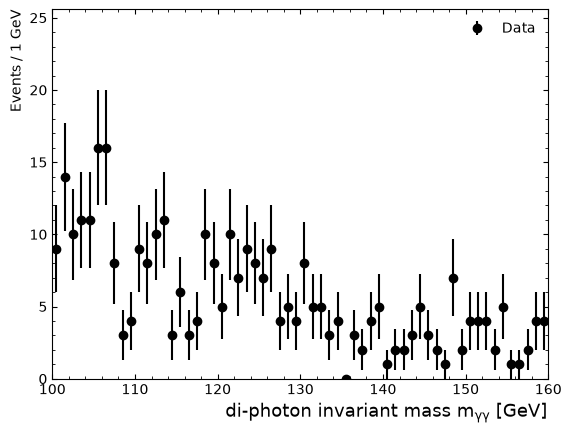

In [51]:
# x-axis range of the plot
xmin = 100 #GeV
xmax = 160 #GeV

# Histogram bin setup
step_size = 1 #GeV
bin_edges = np.arange(start=xmin, # The interval includes this value
                    stop=xmax+step_size, # The interval doesn't include this value
                    step=step_size ) # Spacing between values
bin_centres = np.arange(start=xmin+step_size/2, # The interval includes this value
                        stop=xmax+step_size/2, # The interval doesn't include this value
                        step=step_size ) # Spacing between values

# Creating histogram from data
data_x,_ = np.histogram(ak.to_numpy(data15_periodD),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data


# *************
# Main plot
# *************
main_axes = plt.gca() # get current axes

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ko', # 'k' means black and 'o' is for circles
                    label='Data')

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
main_axes.legend( frameon=False ); # no box around the legend

# Final Analysis

Apply the cuts and calculate the invariant masses. The tutorial looped through all files in `files_list`, but I can't seem to. So I'll download them all and loop through them that way.

In [78]:
from pathlib import Path

# get pathnames of sample data for this tutorial
pathnames = []
dir_path = Path(r'C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw')
for f in dir_path.iterdir():
    pathnames.append(r'C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw' + '\\' + f.name)

print(pathnames)
print()

['C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CE

In [79]:
# conserve pathnames for this tutorial, since the files in data\raw may change eventually
pathnames = ['C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodB.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodC.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodD.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodE.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodF.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodG.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodI.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodK.GamGam.root', 'C:\\Users\\mibaw\\Particle_Physics\\CERN_Data_Analysis\\data\\raw\\ODEO_FEB2025_v0_GamGam_data16_periodL.GamGam.root']

print(len(pathnames))


16


In [80]:
# Controls the fraction of all the events analysed. All of the data is used by
# default to run this analysis (implemented in the loop over the tree). Reduce
# this if you want the code to run quicker. This can take several minutes to
# process the entire dataset
fraction = 1
# Holder for the masses as we process the files
sample_data = []

# Loop over all the files in our list
for afile in pathnames:

    # Print which sample is being processed
    print(f'Processing file {afile} ({pathnames.index(afile)+1}/{len(pathnames)})')

    # Open file
    tree = uproot.open(afile + ":analysis")

    numevents = tree.num_entries

    # Perform the cuts for each data entry in the tree and calculate the invariant mass
    for data in tree.iterate(variables, library="ak", entry_stop=numevents*fraction):

        photon_isTightID = data['photon_isTightID']
        data = data[cut_photon_reconstruction(photon_isTightID)]

        photon_pt = data['photon_pt']
        data = data[cut_photon_pt(photon_pt)]

        data = data[cut_isolation_pt(data['photon_ptcone20'],data['photon_pt'])]

        photon_eta = data['photon_eta']
        data = data[cut_photon_eta_transition(photon_eta)]

        data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'], data['photon_phi'], data['photon_e'])

        data = data[cut_mass(data['mass'])]

        data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

        # Append data to the whole sample data list
        sample_data.append(data['mass'])

print('Done processing data')

# turns sample_data back into an awkward array
all_data = ak.concatenate(sample_data)

Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root (1/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root (2/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root (3/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root (4/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root (5/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root (6/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data16_periodA.GamGam.root (7/16)
Processing file C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\da

Copy pasted: We are now ready to fit our data to effectively detect the Higgs boson! We will use a combination of a 4th order polynomial and a Gaussian function. The polynomial function represents the background, while the Gaussian function represents our signal. The Gaussian model is used to fit the signal due to the nature of the detector's resolution. The fourth-order polynomial is chosen for the background because it offers enough flexibility to capture the overall shape without overfitting, thereby reducing the influence of spurious data—random, irrelevant fluctuations or noise that do not correspond to the true signal or background.

In [48]:

data_x,_ = np.histogram(ak.to_numpy(all_data),
                            bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data


print("bins:", np.sum(data_x))
print("Zero-count bins:", np.sum(data_x == 0))
print("Non-finite weights:", np.sum(~np.isfinite(1 / data_x_errors)))

bins: 592
Zero-count bins: 31
Non-finite weights: 31


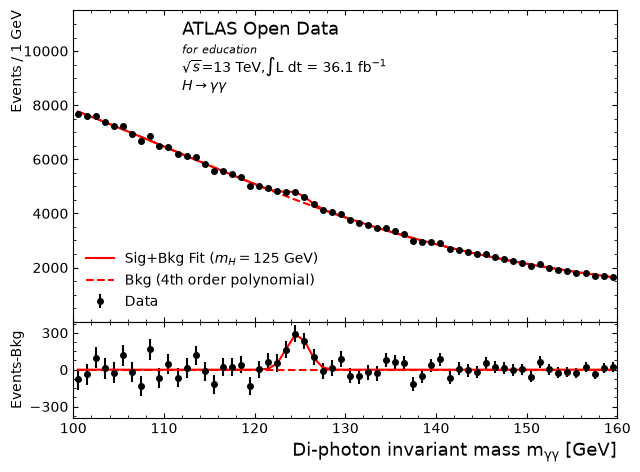

In [81]:
data_x,_ = np.histogram(ak.to_numpy(all_data),
                            bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

# data fit
polynomial_mod = PolynomialModel( 4 ) # 4th order polynomial
gaussian_mod = GaussianModel() # Gaussian

# set initial guesses for the parameters of the polynomial model
# c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
pars = polynomial_mod.guess(data_x, # data to use to guess parameter values
                            x=bin_centres, c0=data_x.max(), c1=0,
                            c2=0, c3=0, c4=0 )

# set initial guesses for the parameters of the Gaussian model
pars += gaussian_mod.guess(data_x, # data to use to guess parameter values
                        x=bin_centres, amplitude=100,
                        center=125, sigma=2 )

model = polynomial_mod + gaussian_mod # combined model

# NOTE: chatgpt fix
'''weights = np.zeros_like(data_x, dtype=float)

nonempty = data_x > 0
weights[nonempty] = 1.0 / data_x_errors[nonempty]'''

# fit the model to the data
out = model.fit(data_x, # data to be fit
                pars, # guesses for the parameters
                x=bin_centres, weights=1/data_x_errors ) #ASK
                #weights=weights)

# background part of fit
params_dict = out.params.valuesdict() # get the parameters from the fit to data
c0 = params_dict['c0'] # c0 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c1 = params_dict['c1'] # c1 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c2 = params_dict['c2'] # c2 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c3 = params_dict['c3'] # c3 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c4 = params_dict['c4'] # c4 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4

# get the background only part of the fit to data
background = c0 + c1*bin_centres + c2*bin_centres**2 + c3*bin_centres**3 + c4*bin_centres**4

# data fit - background fit = signal fit
signal_x = data_x - background

# *************
# Main plot
# *************
plt.axes([0.1,0.3,0.85,0.65]) # left, bottom, width, height
main_axes = plt.gca() # get current axes

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                fmt='ko', # 'k' means black and 'o' means circles
                label='Data', markersize=4 )

# plot the signal + background fit
main_axes.plot(bin_centres, # x
            out.best_fit, # y
            '-r', # single red line
            label='Sig+Bkg Fit ($m_H=125$ GeV)' )

# plot the background only fit
main_axes.plot(bin_centres, # x
            background, # y
            '--r', # dashed red line
            label='Bkg (4th order polynomial)' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x-axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                    direction='in', # Put ticks inside and outside the axes
                    top=True, # draw ticks on the top axis
                    labelbottom=False, # don't draw tick labels on bottom axis
                    right=True ) # draw ticks on right axis

# write y-axis label for main
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                    horizontalalignment='right')

# set the y-axis limit for the main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.5 )

# set minor ticks on the y-axis of the main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# avoid displaying y=0 on the main axes
main_axes.yaxis.get_major_ticks()[0].set_visible(False)

# Add text 'ATLAS Open Data' on plot
plt.text(0.2, # x
        0.92, # y
        'ATLAS Open Data', # text
        transform=main_axes.transAxes, # coordinate system used is that of main_axes
        fontsize=13 )

# Add text 'for education' on plot
plt.text(0.2, # x
        0.86, # y
        'for education', # text
        transform=main_axes.transAxes, # coordinate system used is that of main_axes
        style='italic',
        fontsize=8 )

lumi = 36.1
lumi_used = str(lumi*fraction) # luminosity to write on the plot
plt.text(0.2, # x
        0.8, # y
        r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+' fb$^{-1}$', # text
        transform=main_axes.transAxes ) # coordinate system used is that of main_axes

# Add a label for the analysis carried out
plt.text(0.2, # x
        0.74, # y
        r'$H \rightarrow \gamma\gamma$', # text
        transform=main_axes.transAxes ) # coordinate system used is that of main_axes

# draw the legend
main_axes.legend(frameon=False, # no box around the legend
                loc='lower left' ) # legend location


# *************
# Data-Bkg plot
# *************
plt.axes([0.1,0.1,0.85,0.2]) # left, bottom, width, height
sub_axes = plt.gca() # get the current axes

# set the y axis to be symmetric about Data-Background=0
sub_axes.yaxis.set_major_locator( MaxNLocator(nbins='auto',
                                            symmetric=True) )

# plot Data-Background
sub_axes.errorbar(x=bin_centres, y=signal_x, yerr=data_x_errors,
                fmt='ko',markersize=4 ) # 'k' means black and 'o' means circles

# draw the fit to data
sub_axes.plot(bin_centres, # x
            out.best_fit-background, # y
            '-r' ) # single red line

# draw the background only fit
sub_axes.plot(bin_centres, # x
            background-background, # y
            '--r' )  # dashed red line

# set the x-axis limits on the sub axes
sub_axes.set_xlim( left=xmin, right=xmax )

# separation of x-axis minor ticks
sub_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# x-axis label
sub_axes.set_xlabel(r'Di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    x=1, horizontalalignment='right',
                    fontsize=13 )

# set the tick parameters for the sub axes
sub_axes.tick_params(which='both', # ticks on both x and y axes
                    direction='in', # Put ticks inside and outside the axes
                    top=True, # draw ticks on the top axis
                    right=True ) # draw ticks on right axis

# separation of y-axis minor ticks
sub_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# y-axis label on the sub axes
sub_axes.set_ylabel( 'Events-Bkg' )


# Generic features for both plots
main_axes.yaxis.set_label_coords( -0.09, 1 ) # x,y coordinates of the y-axis label on the main axes
sub_axes.yaxis.set_label_coords( -0.09, 0.5 ) # x,y coordinates of the y-axis label on the sub axes

# No messing around, all copy paste except data file loc

In [56]:
# Accessing the file from the online database (":analysis" opens the tree in a desired manner)
tree = uproot.open(r"C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root" ":analysis")
# The number of entries in the tree can be viewed
print("The number of entries in the tree are:", tree.num_entries)

# All the information stored in the tree can be viewed using the .keys() method.
print("The information stored in the tree is:", tree.keys())

The number of entries in the tree are: 63195
The information stored in the tree is: ['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'sig_ph', 'n_sig_ph', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMediumID', 

In [57]:
# Cut on the photon reconstruction quality
def cut_photon_reconstruction(photon_isTightID):
    # Only the events which have True for both photons are kept
    return (photon_isTightID[:,0]==True) & (photon_isTightID[:,1]==True)

# Cut on the transverse momentum
def cut_photon_pt(photon_pt):
# Only the events where photon_pt[0] > 50 GeV and photon_pt[1] > 30 GeV are kept
    return (photon_pt[:,0] > 50) & (photon_pt[:,1] > 30)

# Cut on the energy isolation
def cut_isolation_pt(photon_ptcone20, photon_pt):
# Only the events where the calorimeter isolation is less than 5.5% are kept
    return ((photon_ptcone20[:,0]/photon_pt[:,0]) < 0.055) & ((photon_ptcone20[:,1]/photon_pt[:,1]) < 0.055)

# Cut on the pseudorapidity in barrel/end-cap transition region
def cut_photon_eta_transition(photon_eta):
# Only the events where modulus of photon_eta is outside the range 1.37 to 1.52 are kept
    condition_0 = (np.abs(photon_eta[:, 0]) < 1.52) | (np.abs(photon_eta[:, 0]) > 1.37)
    condition_1 = (np.abs(photon_eta[:, 1]) < 1.52) | (np.abs(photon_eta[:, 1]) > 1.37)
    return condition_0 & condition_1

# This function calculates the invariant mass of the 2-photon state
def calc_mass(photon_pt, photon_eta, photon_phi, photon_e):
    p4 = vector.zip({"pt": photon_pt, "eta": photon_eta, "phi": photon_phi, "e": photon_e})
    invariant_mass = (p4[:, 0] + p4[:, 1]).M # .M calculates the invariant mass
    return invariant_mass

# Cut on null diphoton invariant mass
def cut_mass(invariant_mass):
    return (invariant_mass != 0)

# Cut on the pT relative to the invariant mass
# Only the events where the invididual photon pT is larger than 35% of the invariant mass are kept
def cut_iso_mass(photon_pt, invariant_mass):
    return ((photon_pt[:,0]/invariant_mass) > 0.35) & ((photon_pt[:,1]/invariant_mass) > 0.35)

In [58]:
# Define empty list to hold all data for this sample
sample_data = []

# Perform the cuts for each data entry in the tree
for data in tree.iterate(variables, library="ak"):

    photon_isTightID = data['photon_isTightID']
    data = data[cut_photon_reconstruction(photon_isTightID)]

    photon_pt = data['photon_pt']
    data = data[cut_photon_pt(photon_pt)]

    data = data[cut_isolation_pt(data['photon_ptcone20'],data['photon_pt'])]

    photon_eta = data['photon_eta']
    data = data[cut_photon_eta_transition(photon_eta)]

    data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'], data['photon_phi'], data['photon_e'])

    data = data[cut_mass(data['mass'])]

    data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

    # Append data to the whole sample data list
    sample_data.append(data['mass'])

# turn sample_data back into an awkward array
data15_periodD = ak.concatenate(sample_data)

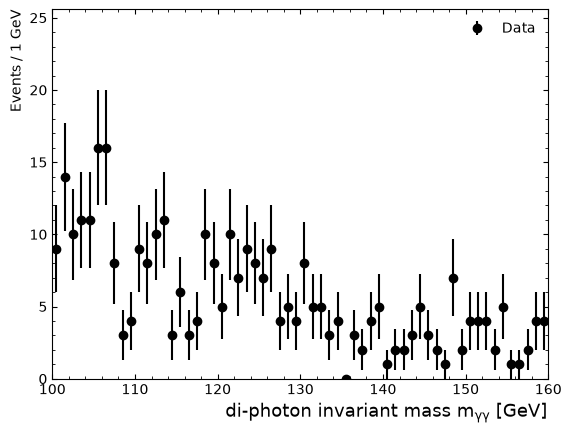

In [59]:
# x-axis range of the plot
xmin = 100 #GeV
xmax = 160 #GeV

# Histogram bin setup
step_size = 1 #GeV
bin_edges = np.arange(start=xmin, # The interval includes this value
                    stop=xmax+step_size, # The interval doesn't include this value
                    step=step_size ) # Spacing between values
bin_centres = np.arange(start=xmin+step_size/2, # The interval includes this value
                        stop=xmax+step_size/2, # The interval doesn't include this value
                        step=step_size ) # Spacing between values

# Creating histogram from data
data_x,_ = np.histogram(ak.to_numpy(data15_periodD),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data


# *************
# Main plot
# *************
main_axes = plt.gca() # get current axes

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ko', # 'k' means black and 'o' is for circles
                    label='Data')

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
main_axes.legend( frameon=False ); # no box around the legend

In [61]:
# Controls the fraction of all the events analysed. All of the data is used by
# default to run this analysis (implemented in the loop over the tree). Reduce
# this if you want the code to run quicker. This can take several minutes to
# process the entire dataset
fraction = 1
# Holder for the masses as we process the files
sample_data = []

# Loop over all the files in our list
for afile in files_list:

    # Print which sample is being processed
    print(f'Processing file {afile} ({files_list.index(afile)+1}/{len(files_list)})')

    # Open file
    tree = uproot.open(r"C:\Users\mibaw\Particle_Physics\CERN_Data_Analysis\data\raw\ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root" + ":analysis")

    numevents = tree.num_entries

    # Perform the cuts for each data entry in the tree and calculate the invariant mass
    for data in tree.iterate(variables, library="ak", entry_stop=numevents*fraction):

        photon_isTightID = data['photon_isTightID']
        data = data[cut_photon_reconstruction(photon_isTightID)]

        photon_pt = data['photon_pt']
        data = data[cut_photon_pt(photon_pt)]

        data = data[cut_isolation_pt(data['photon_ptcone20'],data['photon_pt'])]

        photon_eta = data['photon_eta']
        data = data[cut_photon_eta_transition(photon_eta)]

        data['mass'] = calc_mass(data['photon_pt'], data['photon_eta'], data['photon_phi'], data['photon_e'])

        data = data[cut_mass(data['mass'])]

        data = data[cut_iso_mass(data['photon_pt'], data['mass'])]

        # Append data to the whole sample data list
        sample_data.append(data['mass'])

print('Done processing data')

# turns sample_data back into an awkward array
all_data = ak.concatenate(sample_data)

Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodD.GamGam.root (1/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodE.GamGam.root (2/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodF.GamGam.root (3/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodG.GamGam.root (4/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodH.GamGam.root (5/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data15_periodJ.GamGam.root (6/16)
Processing file simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_GamGam_data16_periodA.GamG

In [63]:
data_x,_ = np.histogram(ak.to_numpy(all_data),
                            bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

print("Total selected events:", len(all_data))
print("Histogram counts:", data_x)
print("Number of empty bins:", np.count_nonzero(data_x == 0))

original_weights = 1 / data_x_errors
print("Weights:", original_weights)
print("Non-finite weights:", np.count_nonzero(~np.isfinite(original_weights)))

Total selected events: 12640
Histogram counts: [144 224 160 176 176 256 256 128  48  64 144 128 160 176  48  96  48  64
 160 128  80 160 112 144 128 112 144  64  80  64 128  80  80  48  64   0
  48  32  64  80  16  32  32  48  80  48  32  16 112  32  64  64  64  32
  80  16  16  32  64  64]
Number of empty bins: 1
Weights: [0.08333333 0.06681531 0.07905694 0.07537784 0.07537784 0.0625
 0.0625     0.08838835 0.14433757 0.125      0.08333333 0.08838835
 0.07905694 0.07537784 0.14433757 0.10206207 0.14433757 0.125
 0.07905694 0.08838835 0.1118034  0.07905694 0.09449112 0.08333333
 0.08838835 0.09449112 0.08333333 0.125      0.1118034  0.125
 0.08838835 0.1118034  0.1118034  0.14433757 0.125             inf
 0.14433757 0.1767767  0.125      0.1118034  0.25       0.1767767
 0.1767767  0.14433757 0.1118034  0.14433757 0.1767767  0.25
 0.09449112 0.1767767  0.125      0.125      0.125      0.1767767
 0.1118034  0.25       0.25       0.1767767  0.125      0.125     ]
Non-finite weights: 1


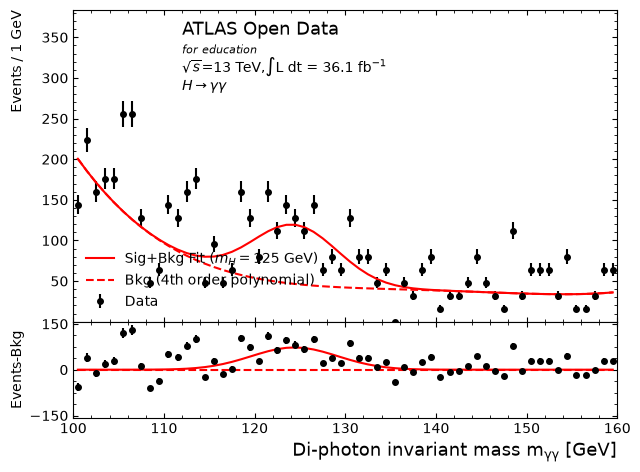

In [64]:
data_x,_ = np.histogram(ak.to_numpy(all_data),
                            bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

# data fit
polynomial_mod = PolynomialModel( 4 ) # 4th order polynomial
gaussian_mod = GaussianModel() # Gaussian

# set initial guesses for the parameters of the polynomial model
# c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
pars = polynomial_mod.guess(data_x, # data to use to guess parameter values
                            x=bin_centres, c0=data_x.max(), c1=0,
                            c2=0, c3=0, c4=0 )

# set initial guesses for the parameters of the Gaussian model
pars += gaussian_mod.guess(data_x, # data to use to guess parameter values
                        x=bin_centres, amplitude=100,
                        center=125, sigma=2 )

model = polynomial_mod + gaussian_mod # combined model

# NOTE: chatgpt fix
weights = np.zeros_like(data_x, dtype=float)

nonempty = data_x > 0
weights[nonempty] = 1.0 / data_x_errors[nonempty]

# fit the model to the data
out = model.fit(data_x, # data to be fit
                pars, # guesses for the parameters
                x=bin_centres, #weights=1/data_x_errors ) #ASK
                weights=weights)

# background part of fit
params_dict = out.params.valuesdict() # get the parameters from the fit to data
c0 = params_dict['c0'] # c0 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c1 = params_dict['c1'] # c1 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c2 = params_dict['c2'] # c2 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c3 = params_dict['c3'] # c3 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
c4 = params_dict['c4'] # c4 of c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4

# get the background only part of the fit to data
background = c0 + c1*bin_centres + c2*bin_centres**2 + c3*bin_centres**3 + c4*bin_centres**4

# data fit - background fit = signal fit
signal_x = data_x - background

# *************
# Main plot
# *************
plt.axes([0.1,0.3,0.85,0.65]) # left, bottom, width, height
main_axes = plt.gca() # get current axes

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                fmt='ko', # 'k' means black and 'o' means circles
                label='Data', markersize=4 )

# plot the signal + background fit
main_axes.plot(bin_centres, # x
            out.best_fit, # y
            '-r', # single red line
            label='Sig+Bkg Fit ($m_H=125$ GeV)' )

# plot the background only fit
main_axes.plot(bin_centres, # x
            background, # y
            '--r', # dashed red line
            label='Bkg (4th order polynomial)' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x-axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                    direction='in', # Put ticks inside and outside the axes
                    top=True, # draw ticks on the top axis
                    labelbottom=False, # don't draw tick labels on bottom axis
                    right=True ) # draw ticks on right axis

# write y-axis label for main
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                    horizontalalignment='right')

# set the y-axis limit for the main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.5 )

# set minor ticks on the y-axis of the main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# avoid displaying y=0 on the main axes
main_axes.yaxis.get_major_ticks()[0].set_visible(False)

# Add text 'ATLAS Open Data' on plot
plt.text(0.2, # x
        0.92, # y
        'ATLAS Open Data', # text
        transform=main_axes.transAxes, # coordinate system used is that of main_axes
        fontsize=13 )

# Add text 'for education' on plot
plt.text(0.2, # x
        0.86, # y
        'for education', # text
        transform=main_axes.transAxes, # coordinate system used is that of main_axes
        style='italic',
        fontsize=8 )

lumi = 36.1
lumi_used = str(lumi*fraction) # luminosity to write on the plot
plt.text(0.2, # x
        0.8, # y
        r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+' fb$^{-1}$', # text
        transform=main_axes.transAxes ) # coordinate system used is that of main_axes

# Add a label for the analysis carried out
plt.text(0.2, # x
        0.74, # y
        r'$H \rightarrow \gamma\gamma$', # text
        transform=main_axes.transAxes ) # coordinate system used is that of main_axes

# draw the legend
main_axes.legend(frameon=False, # no box around the legend
                loc='lower left' ) # legend location


# *************
# Data-Bkg plot
# *************
plt.axes([0.1,0.1,0.85,0.2]) # left, bottom, width, height
sub_axes = plt.gca() # get the current axes

# set the y axis to be symmetric about Data-Background=0
sub_axes.yaxis.set_major_locator( MaxNLocator(nbins='auto',
                                            symmetric=True) )

# plot Data-Background
sub_axes.errorbar(x=bin_centres, y=signal_x, yerr=data_x_errors,
                fmt='ko',markersize=4 ) # 'k' means black and 'o' means circles

# draw the fit to data
sub_axes.plot(bin_centres, # x
            out.best_fit-background, # y
            '-r' ) # single red line

# draw the background only fit
sub_axes.plot(bin_centres, # x
            background-background, # y
            '--r' )  # dashed red line

# set the x-axis limits on the sub axes
sub_axes.set_xlim( left=xmin, right=xmax )

# separation of x-axis minor ticks
sub_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# x-axis label
sub_axes.set_xlabel(r'Di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                    x=1, horizontalalignment='right',
                    fontsize=13 )

# set the tick parameters for the sub axes
sub_axes.tick_params(which='both', # ticks on both x and y axes
                    direction='in', # Put ticks inside and outside the axes
                    top=True, # draw ticks on the top axis
                    right=True ) # draw ticks on right axis

# separation of y-axis minor ticks
sub_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# y-axis label on the sub axes
sub_axes.set_ylabel( 'Events-Bkg' )


# Generic features for both plots
main_axes.yaxis.set_label_coords( -0.09, 1 ) # x,y coordinates of the y-axis label on the main axes
sub_axes.yaxis.set_label_coords( -0.09, 0.5 ) # x,y coordinates of the y-axis label on the sub axes

# Annnnnd of course file loc was the problem